In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

In [2]:
# ============================================================
# Common utility functions
# ============================================================

def display_ordered_distribution(
    df,
    factor_col,
    expected_scores=None,
    model_name=None,
    xlabel=None,
    title=None,
    numeric=True,
    figsize=(6, 4)
):
    """
    有序カテゴリ変数の分布を確認する。
    例: Clarity, Artifact, Field definition
    """
    tmp = df[[factor_col]].copy()

    if numeric:
        tmp[factor_col] = pd.to_numeric(tmp[factor_col], errors="coerce")

    print("Total rows:", len(tmp))
    print(f"Missing {factor_col}:", tmp[factor_col].isna().sum())
    print(f"Unique {factor_col} values:")
    print(sorted(tmp[factor_col].dropna().unique()))

    if expected_scores is not None:
        observed_scores = set(tmp[factor_col].dropna().astype(int).unique())
        unexpected_scores = sorted(observed_scores - set(expected_scores))
        print("Unexpected scores:", unexpected_scores if unexpected_scores else "None")

    dist_df = (
        tmp[factor_col]
        .value_counts(dropna=False)
        .rename_axis(factor_col)
        .reset_index(name="count")
    )

    # NaN を最後に並べる
    dist_df["sort_key"] = dist_df[factor_col].fillna(999999)
    dist_df = dist_df.sort_values("sort_key").drop(columns="sort_key")

    dist_df["ratio_%"] = (dist_df["count"] / len(tmp) * 100).round(2)

    display(dist_df)

    print(f"{factor_col} summary:")
    display(tmp[factor_col].describe().to_frame().T)

    # bar plot
    plot_df = dist_df[dist_df[factor_col].notna()].copy()

    plt.figure(figsize=figsize)

    x_labels = plot_df[factor_col].apply(
        lambda x: str(int(x)) if float(x).is_integer() else str(x)
    )

    plt.bar(x_labels, plot_df["count"])

    if title is None:
        title = f"{model_name}: Distribution of {factor_col}" if model_name else f"Distribution of {factor_col}"

    if xlabel is None:
        xlabel = factor_col

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.grid(axis="y")
    plt.show()

    return dist_df

In [3]:
def analyze_pc_spearman_by_factor(
    df,
    pc_col,
    factor_col,
    model_name=None,
    xlabel=None,
    title=None,
    figsize=(7, 4)
):
    """
    PC と有序カテゴリ変数の Spearman 相関を計算する。
    例: PC1 vs Clarity / Artifact / Field definition
    """
    tmp = df[[pc_col, factor_col]].copy()

    tmp[pc_col] = pd.to_numeric(tmp[pc_col], errors="coerce")
    tmp[factor_col] = pd.to_numeric(tmp[factor_col], errors="coerce")

    tmp = tmp.dropna()

    if len(tmp) < 3 or tmp[factor_col].nunique() < 2:
        rho, p_value = np.nan, np.nan
    else:
        rho, p_value = spearmanr(tmp[factor_col], tmp[pc_col])

    result_df = pd.DataFrame([{
        "PC": pc_col,
        "factor": factor_col,
        "n": len(tmp),
        "spearman_rho": rho,
        "abs_rho": abs(rho) if pd.notna(rho) else np.nan,
        "p_value": p_value
    }])

    display(result_df)

    summary_df = (
        tmp.groupby(factor_col)[pc_col]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )

    display(summary_df)

    plt.figure(figsize=figsize)
    tmp.boxplot(column=pc_col, by=factor_col)
    plt.suptitle("")

    if title is None:
        title = f"{model_name}: {pc_col} by {factor_col}" if model_name else f"{pc_col} by {factor_col}"

    if xlabel is None:
        xlabel = factor_col

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(pc_col)
    plt.grid(axis="y")
    plt.show()

    return result_df, summary_df

In [4]:
def analyze_pc_binary_auc(
    df,
    pc_col,
    factor_col,
    value_map,
    model_name=None,
    factor_name=None,
    negative_label=None,
    positive_label=None,
    preprocess_func=None,
    xlabel=None,
    title=None,
    figsize=(6, 4)
):
    """
    PC が二値カテゴリをどの程度区別しているかを AUC で確認する。
    例:
    eye: {"l": 0, "r": 1}
    Overall quality: {0: 0, 1: 1}
    view_no: {1: 0, 2: 1}
    """
    tmp = df[[pc_col, factor_col]].copy()

    tmp[pc_col] = pd.to_numeric(tmp[pc_col], errors="coerce")

    if preprocess_func is not None:
        tmp[factor_col] = preprocess_func(tmp[factor_col])

    tmp["_binary"] = tmp[factor_col].map(value_map)

    tmp = tmp.dropna(subset=[pc_col, factor_col, "_binary"])
    tmp["_binary"] = tmp["_binary"].astype(int)

    if factor_name is None:
        factor_name = factor_col

    if negative_label is None:
        negative_label = "negative"

    if positive_label is None:
        positive_label = "positive"

    print(f"{factor_name} distribution:")
    display(
        tmp[factor_col]
        .value_counts()
        .sort_index()
        .rename_axis(factor_name)
        .reset_index(name="count")
    )

    if tmp["_binary"].nunique() < 2:
        print("AUC cannot be calculated because only one class is present.")
        return None, None

    y = tmp["_binary"].values
    score = tmp[pc_col].values

    auc_raw = roc_auc_score(y, score)
    auc_direction_free = max(auc_raw, 1 - auc_raw)

    result_df = pd.DataFrame([{
        "PC": pc_col,
        "factor": factor_name,
        "negative_label": negative_label,
        "positive_label": positive_label,
        "n": len(tmp),
        "AUC_raw": auc_raw,
        "AUC_direction_free": auc_direction_free,
        "abs_AUC_minus_0.5": abs(auc_raw - 0.5),
        "mean_PC_negative": tmp.loc[tmp["_binary"] == 0, pc_col].mean(),
        "mean_PC_positive": tmp.loc[tmp["_binary"] == 1, pc_col].mean(),
        "median_PC_negative": tmp.loc[tmp["_binary"] == 0, pc_col].median(),
        "median_PC_positive": tmp.loc[tmp["_binary"] == 1, pc_col].median(),
    }])

    display(result_df)

    print(f"{pc_col} summary by {factor_name}:")
    summary_df = (
        tmp.groupby(factor_col)[pc_col]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )

    display(summary_df)

    plt.figure(figsize=figsize)
    tmp.boxplot(column=pc_col, by=factor_col)
    plt.suptitle("")

    if title is None:
        title = f"{model_name}: {pc_col} by {factor_name}" if model_name else f"{pc_col} by {factor_name}"

    if xlabel is None:
        xlabel = factor_name

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(pc_col)
    plt.grid(axis="y")
    plt.show()

    return result_df, summary_df

In [5]:
def analyze_all_pc_spearman(
    df,
    label_col,
    n_pc=50,
    pc_prefix="PC"
):
    """
    PC1〜PCn とラベルの Spearman 相関をまとめて計算する。
    例: PC1〜PC50 vs eye_DR_Level
    """
    rows = []

    for i in range(n_pc):
        pc = f"{pc_prefix}{i+1}"

        tmp = df[[pc, label_col]].copy()
        tmp[pc] = pd.to_numeric(tmp[pc], errors="coerce")
        tmp[label_col] = pd.to_numeric(tmp[label_col], errors="coerce")
        tmp = tmp.dropna()

        if len(tmp) < 3 or tmp[label_col].nunique() < 2:
            rho, p_value = np.nan, np.nan
        else:
            rho, p_value = spearmanr(tmp[pc], tmp[label_col])

        rows.append({
            "PC": pc,
            "n": len(tmp),
            "spearman_rho": rho,
            "abs_rho": abs(rho) if pd.notna(rho) else np.nan,
            "p_value": p_value
        })

    result_df = pd.DataFrame(rows)
    result_df = result_df.sort_values("abs_rho", ascending=False)

    display(result_df.head(20))

    return result_df

In [6]:
def extract_view_no(path):
    """
    image_path から view_no を抽出する。
    例: 5_l1.jpg -> 1, 5_r2.jpg -> 2
    """
    fname = str(path).replace("\\", "/").split("/")[-1].lower()
    m = re.search(r"[lr]([12])(?=\.[^.]+$|$)", fname)

    if m:
        return int(m.group(1))

    return np.nan

### load feature

In [7]:
model_name = "FVs_medsiglip"

npz_path = f"./aligned_features_drvalid/aligned_drvalid_{model_name}.npz"
meta_path = f"./aligned_features_drvalid/aligned_drvalid_{model_name}_metadata.csv"

data = np.load(npz_path, allow_pickle=True)
X = data["X"]

meta_df = pd.read_csv(meta_path)

print("X:", X.shape)
print("metadata:", meta_df.shape)
display(meta_df.head())

display(meta_df["eye_DR_Level"].value_counts().sort_index())

X: (1189, 1152)
metadata: (1189, 12)


,patient_id,image_id,image_path,Overall quality,left_eye_DR_Level,right_eye_DR_Level,patient_DR_Level,Clarity,Field definition,Artifact,eye,eye_DR_Level
0,1,1_l1,\regular-fundus-training\1\1_l1.jpg,0,0.0,NaN,0,8,8,4,l,0.0
1,1,1_l2,\regular-fundus-training\1\1_l2.jpg,0,0.0,NaN,0,8,8,0,l,0.0
2,1,1_r1,\regular-fundus-training\1\1_r1.jpg,0,NaN,0.0,0,8,8,4,r,0.0
3,1,1_r2,\regular-fundus-training\1\1_r2.jpg,0,NaN,0.0,0,10,8,0,r,0.0
4,2,2_l1,\regular-fundus-training\2\2_l1.jpg,0,2.0,NaN,2,10,8,6,l,2.0


eye_DR_Level
0.0    532
1.0    139
2.0    232
3.0    214
4.0     72
Name: count, dtype: int64

### PCA

In [8]:
# 標準化
X_raw = X.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA
n_components = 50

pca = PCA(n_components=n_components, random_state=0)
Z = pca.fit_transform(X_scaled)

print("PCA result:", Z.shape)

print("Explained variance ratio:")
display(pca.explained_variance_ratio_[:10])

print("Cumulative explained variance:")
display(np.cumsum(pca.explained_variance_ratio_)[:10])

PCA result: (1189, 50)
Explained variance ratio:


array([0.16822945, 0.12905145, 0.08837747, 0.07487845, 0.0461589 ,
       0.03623527, 0.03451169, 0.02874907, 0.0254514 , 0.02157432],
      dtype=float32)

Cumulative explained variance:


array([0.16822945, 0.2972809 , 0.38565838, 0.46053684, 0.50669575,
       0.542931  , 0.5774427 , 0.60619175, 0.6316432 , 0.6532175 ],
      dtype=float32)

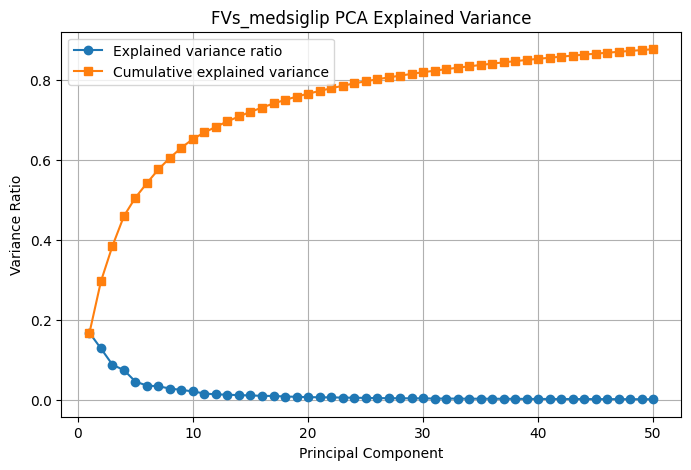

In [9]:
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components + 1), explained, marker="o", label="Explained variance ratio")
plt.plot(range(1, n_components + 1), cum_explained, marker="s", label="Cumulative explained variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.title(f"{model_name} PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
pca_df = meta_df.copy()

for i in range(Z.shape[1]):
    pca_df[f"PC{i+1}"] = Z[:, i]

display(pca_df.head())

,patient_id,image_id,image_path,Overall quality,left_eye_DR_Level,right_eye_DR_Level,patient_DR_Level,Clarity,Field definition,Artifact,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
0,1,1_l1,\regular-fundus-training\1\1_l1.jpg,0,0.0,NaN,0,8,8,4,...,-0.539592,1.494412,0.924922,1.765142,2.088180,-1.394080,0.153395,0.507603,1.284882,0.537035
1,1,1_l2,\regular-fundus-training\1\1_l2.jpg,0,0.0,NaN,0,8,8,0,...,0.017861,-0.155522,0.028570,2.230282,-0.854623,-0.462724,0.408873,-0.646712,1.731559,-1.445824
2,1,1_r1,\regular-fundus-training\1\1_r1.jpg,0,NaN,0.0,0,8,8,4,...,-0.049515,-0.622562,2.515025,-0.245626,-1.332191,-1.494487,0.301673,-1.296637,0.876496,-2.282738
3,1,1_r2,\regular-fundus-training\1\1_r2.jpg,0,NaN,0.0,0,10,8,0,...,-2.594752,-0.232852,0.524813,1.952866,-0.374533,-0.442085,-0.140440,0.488700,1.135891,-2.998279
4,2,2_l1,\regular-fundus-training\2\2_l1.jpg,0,2.0,NaN,2,10,8,6,...,0.398691,0.144278,-2.453766,1.302608,1.538555,0.307455,-0.939416,-1.167635,-1.182510,-0.423395


### DR label distribution

In [11]:
LABEL_COL = "eye_DR_Level"

print("Total rows:", len(meta_df))
print("Missing labels:", meta_df[LABEL_COL].isna().sum())

label_dist = (
    meta_df[LABEL_COL]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("DR_Level")
    .reset_index(name="count")
)

label_dist["ratio_%"] = (
    label_dist["count"] / label_dist["count"].sum() * 100
).round(2)

display(label_dist)

Total rows: 1189
Missing labels: 0


,DR_Level,count,ratio_%
0,0.0,532,44.74
1,1.0,139,11.69
2,2.0,232,19.51
3,3.0,214,18.00
4,4.0,72,6.06


In [12]:
for threshold in [0, 1, 2, 3]:
    y = (meta_df[LABEL_COL] > threshold).astype(int)

    print(f"DR > {threshold}:")
    print(y.value_counts().sort_index())
    print()

DR > 0:
eye_DR_Level
0    532
1    657
Name: count, dtype: int64

DR > 1:
eye_DR_Level
0    671
1    518
Name: count, dtype: int64

DR > 2:
eye_DR_Level
0    903
1    286
Name: count, dtype: int64

DR > 3:
eye_DR_Level
0    1117
1      72
Name: count, dtype: int64



PC1-PC50 DR level spearman

In [13]:
LABEL_COL = "eye_DR_Level"
N_PC = 50

spearman_df = analyze_all_pc_spearman(
    df=pca_df,
    label_col=LABEL_COL,
    n_pc=N_PC
)

,PC,n,spearman_rho,abs_rho,p_value
0,PC1,1189,-0.787509,0.787509,8.999141e-252
2,PC3,1189,-0.120237,0.120237,3.228357e-05
8,PC9,1189,0.116171,0.116171,5.939931e-05
4,PC5,1189,-0.091602,0.091602,1.567294e-03
7,PC8,1189,-0.059665,0.059665,3.968199e-02
5,PC6,1189,0.057047,0.057047,4.922814e-02
11,PC12,1189,0.056792,0.056792,5.024980e-02
3,PC4,1189,-0.055953,0.055953,5.375083e-02
30,PC31,1189,-0.055550,0.055550,5.550234e-02
42,PC43,1189,-0.054977,0.054977,5.807127e-02


,PC,label,n,spearman_rho,abs_rho,p_value
0,PC1,eye_DR_Level,1189,-0.787509,0.787509,8.999141e-252


,eye_DR_Level,count,mean,std,median,min,max
0,0.0,532,11.263342,8.527180,12.659557,-17.592566,26.164639
1,1.0,139,5.299660,7.327280,5.557725,-15.518842,22.430807
2,2.0,232,-11.314476,7.788920,-13.006645,-25.553719,13.291148
3,3.0,214,-14.860353,5.977955,-15.234951,-25.127960,-0.589164
4,4.0,72,-12.828849,6.028564,-14.393599,-23.055935,2.955026


<Figure size 700x400 with 0 Axes>

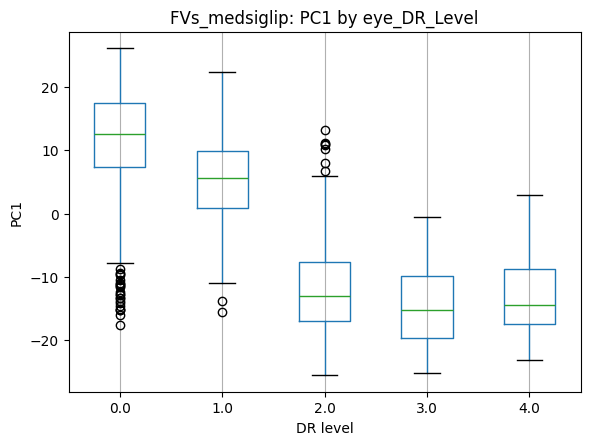

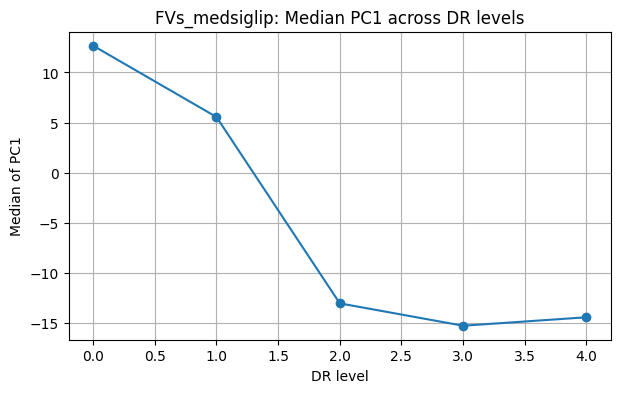

In [25]:
# PC1 と DR 重症度の単調関係を可視化

PC_COL = "PC1"
GRADE_COL = "eye_DR_Level"

tmp = pca_df[[PC_COL, GRADE_COL]].copy()
tmp[PC_COL] = pd.to_numeric(tmp[PC_COL], errors="coerce")
tmp[GRADE_COL] = pd.to_numeric(tmp[GRADE_COL], errors="coerce")
tmp = tmp.dropna()

# Spearman
rho, p_value = spearmanr(tmp[PC_COL], tmp[GRADE_COL])

result_df = pd.DataFrame([{
    "PC": PC_COL,
    "label": GRADE_COL,
    "n": len(tmp),
    "spearman_rho": rho,
    "abs_rho": abs(rho),
    "p_value": p_value
}])

display(result_df)

# 各DR levelの要約
dr_summary_df = (
    tmp.groupby(GRADE_COL)[PC_COL]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
    .sort_values(GRADE_COL)
)

display(dr_summary_df)

# 箱ひげ図
plt.figure(figsize=(7, 4))
tmp.boxplot(column=PC_COL, by=GRADE_COL)
plt.suptitle("")
plt.title(f"{model_name}: {PC_COL} by {GRADE_COL}")
plt.xlabel("DR level")
plt.ylabel(PC_COL)
plt.grid(axis="y")
plt.show()

# 中央値の推移
plt.figure(figsize=(7, 4))
plt.plot(dr_summary_df[GRADE_COL], dr_summary_df["median"], marker="o")
plt.xlabel("DR level")
plt.ylabel(f"Median of {PC_COL}")
plt.title(f"{model_name}: Median {PC_COL} across DR levels")
plt.grid(True)
plt.show()

PC1 を DR level ごとに可視化したところ、DR 重症度の上昇に伴って PC1 の分布は全体として低下する傾向を示した。特に DR level 0–1 と 2–4 の間で分布の差が大きく、PC1 が DR 重症度に関連する特徴を強く反映していることが示唆された。一方で、DR level 3 と 4 の間では中央値の差は小さく、完全な単調変化ではなかった。

PC1 l r AUC

eye distribution:


,eye,count
0,l,594
1,r,595


,PC,factor,negative_label,positive_label,n,AUC_raw,AUC_direction_free,abs_AUC_minus_0.5,mean_PC_negative,mean_PC_positive,median_PC_negative,median_PC_positive
0,PC1,eye,l,r,1189,0.497739,0.502261,0.002261,0.042585,-0.042513,1.085639,1.550115


PC1 summary by eye:


,eye,count,mean,std,median,min,max
0,l,594,0.042585,14.105858,1.085639,-25.553719,26.164639
1,r,595,-0.042513,13.758000,1.550115,-25.127960,24.126062


<Figure size 600x400 with 0 Axes>

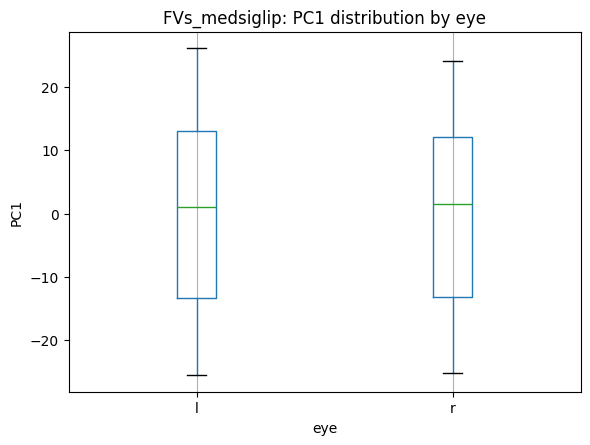

In [14]:
PC_COL = "PC1"
EYE_COL = "eye"

eye_auc_df, eye_summary_df = analyze_pc_binary_auc(
    df=pca_df,
    pc_col=PC_COL,
    factor_col=EYE_COL,
    value_map={"l": 0, "r": 1},
    model_name=model_name,
    factor_name="eye",
    negative_label="l",
    positive_label="r",
    preprocess_func=lambda s: s.astype(str).str.lower().str.strip(),
    xlabel="eye",
    title=f"{model_name}: {PC_COL} distribution by eye"
)

Overall quality distribution

Total rows: 1189
Missing Overall quality: 0
Unique Overall quality values:
[np.int64(0), np.int64(1)]
Unexpected scores: None


,Overall quality,count,ratio_%
0,0,620,52.14
1,1,569,47.86


Overall quality summary:


,count,mean,std,min,25%,50%,75%,max
Overall quality,1189.0,0.478553,0.49975,0.0,0.0,0.0,1.0,1.0


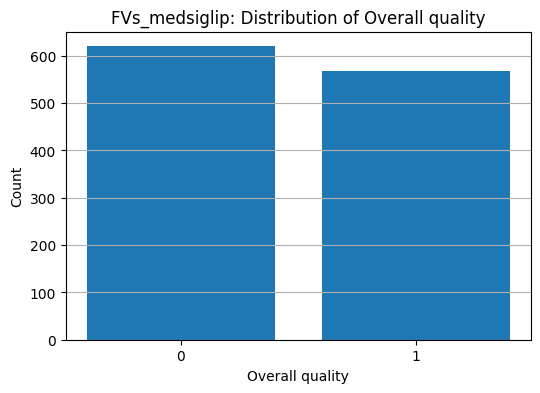

In [15]:
QUALITY_COL = "Overall quality"

quality_dist = display_ordered_distribution(
    df=pca_df,
    factor_col=QUALITY_COL,
    expected_scores={0, 1},
    model_name=model_name,
    xlabel="Overall quality",
    title=f"{model_name}: Distribution of Overall quality"
)

Overall quality AUC

Overall quality distribution:


,Overall quality,count
0,0,620
1,1,569


,PC,factor,negative_label,positive_label,n,AUC_raw,AUC_direction_free,abs_AUC_minus_0.5,mean_PC_negative,mean_PC_positive,median_PC_negative,median_PC_positive
0,PC1,Overall quality,0,1,1189,0.472544,0.527456,0.027456,0.600013,-0.653793,2.444187,0.292198


PC1 summary by Overall quality:


,Overall quality,count,mean,std,median,min,max
0,0,620,0.600013,13.098290,2.444187,-25.553719,24.526714
1,1,569,-0.653793,14.761187,0.292198,-25.127960,26.164639


<Figure size 600x400 with 0 Axes>

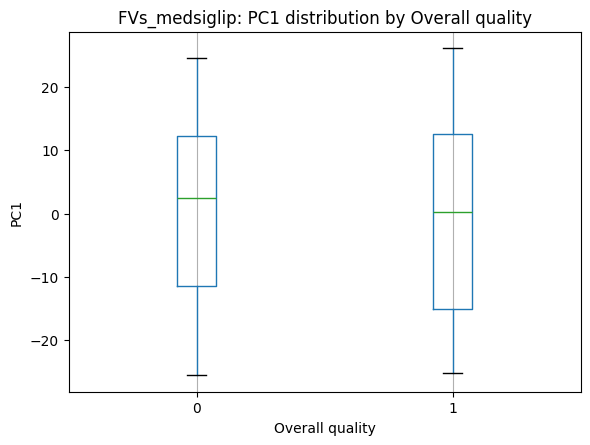

In [16]:
PC_COL = "PC1"
QUALITY_COL = "Overall quality"

quality_auc_df, quality_summary_df = analyze_pc_binary_auc(
    df=pca_df,
    pc_col=PC_COL,
    factor_col=QUALITY_COL,
    value_map={0: 0, 1: 1},
    model_name=model_name,
    factor_name="Overall quality",
    negative_label=0,
    positive_label=1,
    xlabel="Overall quality",
    title=f"{model_name}: {PC_COL} distribution by Overall quality"
)

view_no AUC

view_no distribution:


,view_no,count
0,1,594
1,2,595


,PC,factor,negative_label,positive_label,n,AUC_raw,AUC_direction_free,abs_AUC_minus_0.5,mean_PC_negative,mean_PC_positive,median_PC_negative,median_PC_positive
0,PC1,view_no,view1,view2,1189,0.515935,0.515935,0.015935,-0.365522,0.364908,0.380955,2.300424


PC1 summary by view_no:


,view_no,count,mean,std,median,min,max
0,1,594,-0.365522,13.249619,0.380955,-25.553719,25.422598
1,2,595,0.364908,14.574039,2.300424,-25.127960,26.164639


<Figure size 600x400 with 0 Axes>

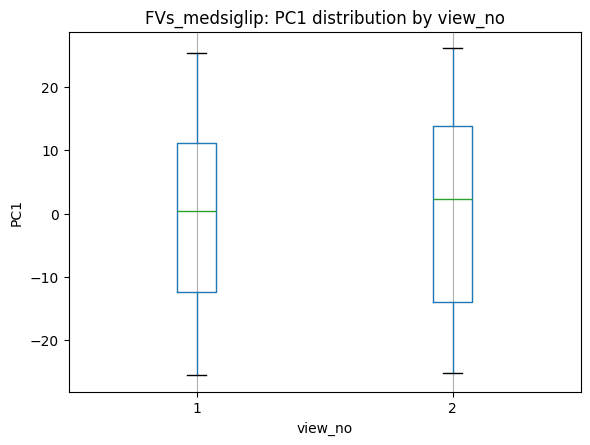

In [17]:
PC_COL = "PC1"
PATH_COL = "image_path"

pca_df["view_no"] = pca_df[PATH_COL].apply(extract_view_no)

view_auc_df, view_summary_df = analyze_pc_binary_auc(
    df=pca_df,
    pc_col=PC_COL,
    factor_col="view_no",
    value_map={1: 0, 2: 1},
    model_name=model_name,
    factor_name="view_no",
    negative_label="view1",
    positive_label="view2",
    xlabel="view_no",
    title=f"{model_name}: {PC_COL} distribution by view_no"
)

Clarity distribution

Total rows: 1189
Missing Clarity: 0
Unique Clarity values:
[np.int64(1), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]
Unexpected scores: None


,Clarity,count,ratio_%
4,1,29,2.44
3,4,85,7.15
2,6,256,21.53
1,8,391,32.88
0,10,428,36.00


Clarity summary:


,count,mean,std,min,25%,50%,75%,max
Clarity,1189.0,7.832632,2.148465,1.0,6.0,8.0,10.0,10.0


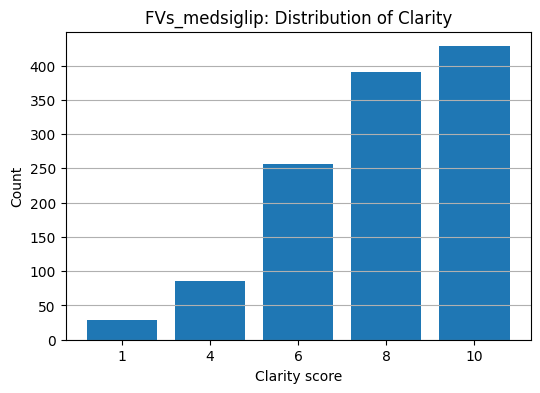

In [18]:
CLARITY_COL = "Clarity"

clarity_dist = display_ordered_distribution(
    df=pca_df,
    factor_col=CLARITY_COL,
    expected_scores={1, 4, 6, 8, 10},
    model_name=model_name,
    xlabel="Clarity score",
    title=f"{model_name}: Distribution of Clarity"
)

Clarity Spearman

,PC,factor,n,spearman_rho,abs_rho,p_value
0,PC1,Clarity,1189,-0.097083,0.097083,0.000802


,Clarity,count,mean,std,median,min,max
0,1,29,0.227219,11.105088,-0.605072,-21.380287,18.716547
1,4,85,-0.852758,12.661635,-3.601409,-22.028389,23.464945
2,6,256,1.745384,13.913807,3.642278,-23.430620,26.164639
3,8,391,1.385331,13.781146,3.816984,-23.186741,24.193617
4,10,428,-2.155578,14.232191,-1.938741,-25.553719,24.126062


<Figure size 700x400 with 0 Axes>

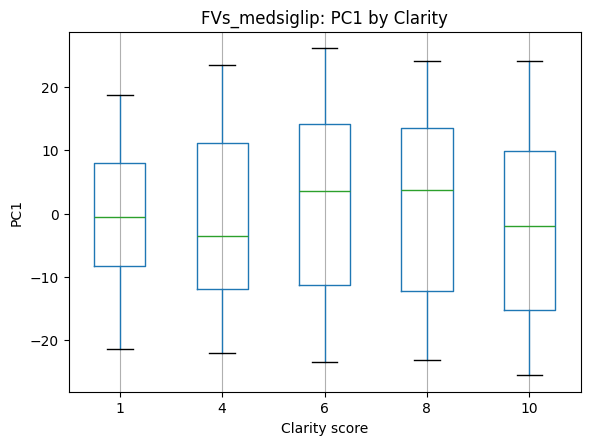

In [19]:
PC_COL = "PC1"
CLARITY_COL = "Clarity"

clarity_spearman_df, clarity_summary_df = analyze_pc_spearman_by_factor(
    df=pca_df,
    pc_col=PC_COL,
    factor_col=CLARITY_COL,
    model_name=model_name,
    xlabel="Clarity score",
    title=f"{model_name}: {PC_COL} by Clarity"
)

Artifact distribution

Total rows: 1189
Missing Artifact: 0
Unique Artifact values:
[np.int64(0), np.int64(1), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]
Unexpected scores: None


,Artifact,count,ratio_%
0,0,592,49.79
4,1,45,3.78
1,4,238,20.02
2,6,146,12.28
3,8,131,11.02
5,10,37,3.11


Artifact summary:


,count,mean,std,min,25%,50%,75%,max
Artifact,1189.0,2.767872,3.189304,0.0,0.0,1.0,6.0,10.0


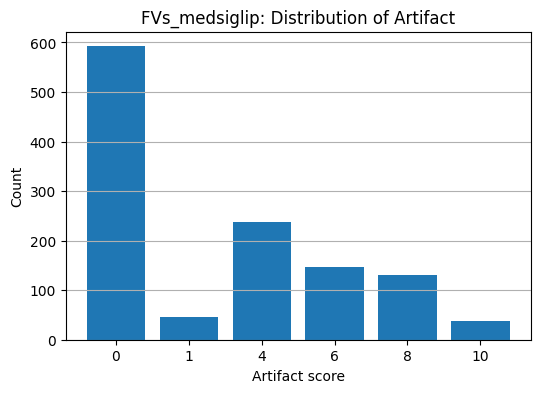

In [20]:
ARTIFACT_COL = "Artifact"

artifact_dist = display_ordered_distribution(
    df=pca_df,
    factor_col=ARTIFACT_COL,
    expected_scores={0, 1, 4, 6, 8, 10},
    model_name=model_name,
    xlabel="Artifact score",
    title=f"{model_name}: Distribution of Artifact"
)

Artifact Spearman

,PC,factor,n,spearman_rho,abs_rho,p_value
0,PC1,Artifact,1189,-0.135486,0.135486,0.000003


,Artifact,count,mean,std,median,min,max
0,0,592,2.031445,14.345150,5.193042,-25.127960,26.164639
1,1,45,3.288856,13.495730,7.699512,-21.807838,23.906040
2,4,238,-3.116056,13.678328,-6.147876,-25.553719,23.007038
3,6,146,-2.669828,12.844759,-4.983861,-23.283087,25.422598
4,8,131,-1.672510,12.578469,-3.863491,-22.325600,23.464945
5,10,37,-0.002677,12.150790,-0.605072,-23.430620,17.702631


<Figure size 700x400 with 0 Axes>

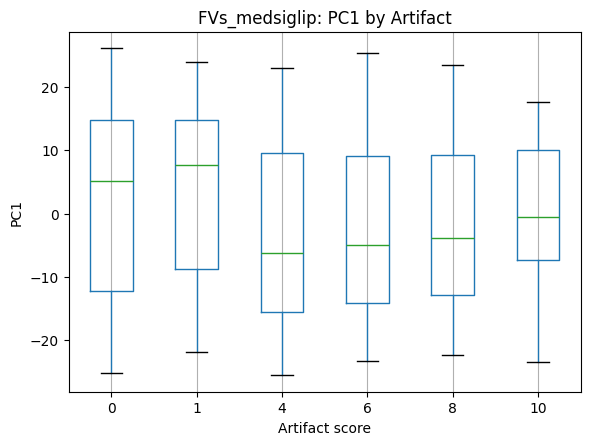

In [21]:
PC_COL = "PC1"
ARTIFACT_COL = "Artifact"

artifact_spearman_df, artifact_summary_df = analyze_pc_spearman_by_factor(
    df=pca_df,
    pc_col=PC_COL,
    factor_col=ARTIFACT_COL,
    model_name=model_name,
    xlabel="Artifact score",
    title=f"{model_name}: {PC_COL} by Artifact"
)

Field definition distribution

Total rows: 1189
Missing Field definition: 0
Unique Field definition values:
[np.int64(1), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]
Unexpected scores: None


,Field definition,count,ratio_%
4,1,6,0.50
3,4,45,3.78
1,6,178,14.97
0,8,799,67.20
2,10,161,13.54


Field definition summary:


,count,mean,std,min,25%,50%,75%,max
Field definition,1189.0,7.784693,1.395906,1.0,8.0,8.0,8.0,10.0


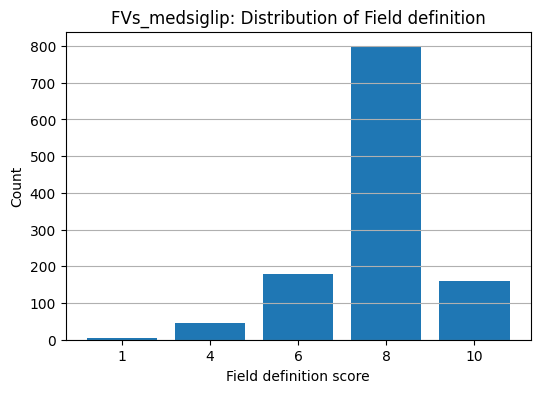

In [22]:
FIELD_COL = "Field definition"

field_dist = display_ordered_distribution(
    df=pca_df,
    factor_col=FIELD_COL,
    expected_scores={1, 4, 6, 8, 10},
    model_name=model_name,
    xlabel="Field definition score",
    title=f"{model_name}: Distribution of Field definition"
)

Field Spearman

,PC,factor,n,spearman_rho,abs_rho,p_value
0,PC1,Field definition,1189,0.094805,0.094805,0.001064


,Field definition,count,mean,std,median,min,max
0,1,6,2.034162,10.341793,4.092327,-10.771757,17.557945
1,4,45,-2.017670,11.799124,0.454125,-22.110058,19.161556
2,6,178,-5.531737,11.730518,-7.618398,-25.553719,22.996634
3,8,799,1.550359,14.058609,4.400739,-25.127960,26.164639
4,10,161,-1.090045,14.561264,-0.545344,-25.027676,23.744459


<Figure size 700x400 with 0 Axes>

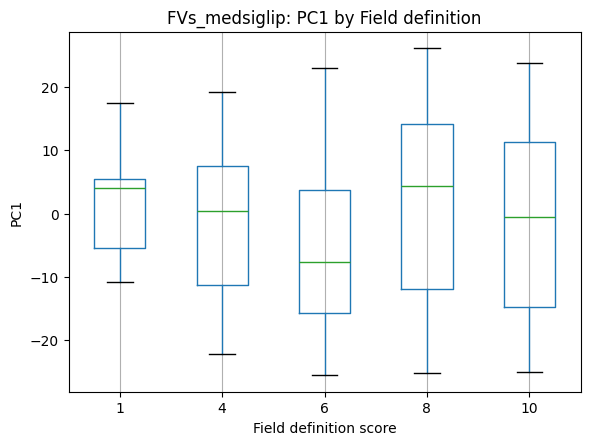

In [23]:
PC_COL = "PC1"
FIELD_COL = "Field definition"

field_spearman_df, field_summary_df = analyze_pc_spearman_by_factor(
    df=pca_df,
    pc_col=PC_COL,
    factor_col=FIELD_COL,
    model_name=model_name,
    xlabel="Field definition score",
    title=f"{model_name}: {PC_COL} by Field definition"
)

In [24]:
confound_summary_df = pd.concat([
    pd.DataFrame([{
        "factor": "eye",
        "method": "AUC",
        "metric": "AUC_direction_free",
        "value": eye_auc_df["AUC_direction_free"].iloc[0] if eye_auc_df is not None else np.nan,
        "effect_size": eye_auc_df["abs_AUC_minus_0.5"].iloc[0] if eye_auc_df is not None else np.nan
    }]),
    pd.DataFrame([{
        "factor": "Overall quality",
        "method": "AUC",
        "metric": "AUC_direction_free",
        "value": quality_auc_df["AUC_direction_free"].iloc[0] if quality_auc_df is not None else np.nan,
        "effect_size": quality_auc_df["abs_AUC_minus_0.5"].iloc[0] if quality_auc_df is not None else np.nan
    }]),
    pd.DataFrame([{
        "factor": "view_no",
        "method": "AUC",
        "metric": "AUC_direction_free",
        "value": view_auc_df["AUC_direction_free"].iloc[0] if view_auc_df is not None else np.nan,
        "effect_size": view_auc_df["abs_AUC_minus_0.5"].iloc[0] if view_auc_df is not None else np.nan
    }]),
    pd.DataFrame([{
        "factor": "Clarity",
        "method": "Spearman",
        "metric": "abs_rho",
        "value": clarity_spearman_df["spearman_rho"].iloc[0],
        "effect_size": clarity_spearman_df["abs_rho"].iloc[0]
    }]),
    pd.DataFrame([{
        "factor": "Artifact",
        "method": "Spearman",
        "metric": "abs_rho",
        "value": artifact_spearman_df["spearman_rho"].iloc[0],
        "effect_size": artifact_spearman_df["abs_rho"].iloc[0]
    }]),
    pd.DataFrame([{
        "factor": "Field definition",
        "method": "Spearman",
        "metric": "abs_rho",
        "value": field_spearman_df["spearman_rho"].iloc[0],
        "effect_size": field_spearman_df["abs_rho"].iloc[0]
    }]),
], ignore_index=True)

display(confound_summary_df)

,factor,method,metric,value,effect_size
0,eye,AUC,AUC_direction_free,0.502261,0.002261
1,Overall quality,AUC,AUC_direction_free,0.527456,0.027456
2,view_no,AUC,AUC_direction_free,0.515935,0.015935
3,Clarity,Spearman,abs_rho,-0.097083,0.097083
4,Artifact,Spearman,abs_rho,-0.135486,0.135486
5,Field definition,Spearman,abs_rho,0.094805,0.094805


### 解析結果のまとめ

本解析では、FVs_medsiglip の特徴ベクトルに対して PCA を適用し、各主成分と DR 重症度、および病変以外の要因との関係を画像単位で評価した。

PC1 は `eye_DR_Level` と強い単調関係を示した（Spearman's ρ = -0.788, n = 1189, p = 9.0 × 10^-252）。主成分の符号は任意であるため、負の方向そのものに臨床的意味を与えるべきではないが、相関係数の絶対値が大きいことから、PC1 は DR 重症度に関連する主要な変動軸を捉えている可能性が高い。

一方で、PC1 が病変以外の要因を反映している可能性を検討するため、左右眼、撮影視野番号、および画像品質関連指標との関係を確認した。その結果、左右眼の識別性能は AUC = 0.502、撮影視野番号の識別性能は AUC = 0.516、Overall quality の direction-free AUC は 0.527 であり、いずれもランダム分類に近い値であった。また、画像品質スコアとの単調関係も、Clarity（ρ = -0.097）、Artifact（ρ = -0.135）、Field definition（ρ = 0.095）と弱かった。

以上より、PC1 と DR 重症度との強い関連は、左右眼、撮影視野番号、または本解析で検討した画像品質指標によって主に説明されるものではないと考えられる。Artifact は画像品質関連指標の中では最も大きな関連を示したが、その効果量は小さく、PC1 の主要な要因というよりは、弱い交絡候補として扱うのが妥当である。

ただし、本解析は画像単位で行っており、同一患者または同一眼に由来する複数画像が含まれる可能性がある。そのため、p 値の解釈には注意が必要である。今後は、DR 重症度と各画像品質指標との関係を直接確認したうえで、同様の解析を他の基盤モデルにも拡張する必要がある。